# 02 - Baseline and Validation

Before we train any model, we need two things: a fair way to measure the error,
and a fair way to split the data. This notebook builds both, and then uses them
on a simple baseline.

The baseline gives us the number that every later model has to beat. Without
it, we cannot say whether a complex model is worth its cost.

In [1]:
import sys
from datetime import date
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# Make the src package importable when the notebook runs from notebooks/.
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import DataLoader
from src.metrics import rmspe, rmspe_by
from src.validation import RollingOriginSplit

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

# Open trading days only. A closed day carries no demand signal, and RMSPE
# divides by the real sales, so a day with zero sales cannot be scored.
df = DataLoader(PROJECT_ROOT / "data").load()
print("Rows:  ", f"{df.height:,}")
print("Period:", df["Date"].min(), "to", df["Date"].max())
print("Stores:", df["Store"].n_unique())

Rows:   844,392
Period: 2013-01-01 to 2015-07-31
Stores: 1115


## How we measure the error

Our metric is RMSPE, the root mean square percentage error. It compares every
error with the size of the store.

The example below shows why this matters. Both stores are wrong by 500 units,
but that is half of the sales of the small store and only five percent of the
sales of the large one.

In [2]:
small = rmspe([1_000], [1_500])
large = rmspe([10_000], [10_500])
print(f"Small store: real 1,000, predicted 1,500  -> RMSPE {small:.2f}")
print(f"Large store: real 10,000, predicted 10,500 -> RMSPE {large:.2f}")

# A forecast that is ten percent too low gives the same score for any size.
print(f"\nTen percent too low, both sizes        -> RMSPE {rmspe([100, 5_000], [90, 4_500]):.2f}")

Small store: real 1,000, predicted 1,500  -> RMSPE 0.50
Large store: real 10,000, predicted 10,500 -> RMSPE 0.05

Ten percent too low, both sizes        -> RMSPE 0.10


The metric treats the small store as ten times worse, and this is the behaviour
we want. An error of 500 units is a serious problem for a store that sells
1,000 units a day, but only a detail for a store that sells 10,000.

The second line shows the other side of the same idea. When every prediction is
ten percent too low, the score is 0.10 for every store size.

## The validation windows

The competition hides six weeks of data and asks us to forecast them. Our
validation must have the same shape, so each of our windows is six weeks long
as well.

We build four windows. They follow each other backwards in time, and every
window trains on all the days before it starts.

In [3]:
splitter = RollingOriginSplit(n_splits=4)
folds = list(splitter.split(df))

for fold in folds:
    print(fold.describe())

fold 1: train 2013-01-01 to 2015-02-13 (689,417 rows) | valid 2015-02-14 to 2015-03-27 (40,176 rows)
fold 2: train 2013-01-01 to 2015-03-27 (729,593 rows) | valid 2015-03-28 to 2015-05-08 (37,044 rows)
fold 3: train 2013-01-01 to 2015-05-08 (766,637 rows) | valid 2015-05-09 to 2015-06-19 (37,473 rows)
fold 4: train 2013-01-01 to 2015-06-19 (804,110 rows) | valid 2015-06-20 to 2015-07-31 (40,282 rows)


Each fold trains on more history than the fold before it, because the training
period always starts on the first day of the data. We keep all the history on
purpose: the data holds only two Decembers, and we cannot afford to throw a
season away.

A random split would be much worse here. It would put days from July into the
training set and days from June into the validation set, so the model would
learn from the future of the rows it has to predict.

## The baseline

Our baseline is a simple rule. For each store, each weekday and each promotion
state, it predicts the median sales of the past.

The rule is easy to understand, but it is not weak. It already knows the three
strongest patterns in the data: the level of the store, the shape of the week,
and the effect of a promotion.

In [4]:
def baseline(train: pl.DataFrame, valid: pl.DataFrame) -> pl.DataFrame:
    """Predict the median past sales per store, weekday and promotion state.

    Every value comes from the training rows of the fold, so the baseline
    never looks at the window that it predicts.
    """
    lookup = train.group_by(["Store", "DayOfWeek", "Promo"]).agg(
        pl.col("Sales").median().alias("prediction")
    )
    per_store = train.group_by("Store").agg(pl.col("Sales").median().alias("_store"))
    overall = float(train["Sales"].median())
    return (
        valid.join(lookup, on=["Store", "DayOfWeek", "Promo"], how="left")
        .join(per_store, on="Store", how="left")
        .with_columns(
            pl.col("prediction").fill_null(pl.col("_store")).fill_null(overall)
        )
    )

The two fallbacks matter for stores that were closed for a long time. When a
store has no row for a given weekday and promotion state, we use the median of
that store. When even that is missing, we use the median of the whole training
set. No row is left without a prediction.

In [5]:
scored = {fold.index: baseline(fold.train, fold.valid) for fold in folds}

results = pl.DataFrame([
    {
        "fold": fold.index,
        "window_ends": fold.valid_end,
        "train_rows": fold.train.height,
        "rmspe": rmspe(scored[fold.index]["Sales"], scored[fold.index]["prediction"]),
    }
    for fold in folds
])
print(results)

mean_score = results["rmspe"].mean()
print(f"\nMean RMSPE: {mean_score:.4f}")
print(f"Spread (std): {results['rmspe'].std(ddof=0):.4f}")
print(f"Hardest window is {results['rmspe'].max() / results['rmspe'].min():.2f} times the easiest")

shape: (4, 4)
┌──────┬─────────────┬────────────┬──────────┐
│ fold ┆ window_ends ┆ train_rows ┆ rmspe    │
│ ---  ┆ ---         ┆ ---        ┆ ---      │
│ i64  ┆ date        ┆ i64        ┆ f64      │
╞══════╪═════════════╪════════════╪══════════╡
│ 1    ┆ 2015-03-27  ┆ 689417     ┆ 0.187735 │
│ 2    ┆ 2015-05-08  ┆ 729593     ┆ 0.174555 │
│ 3    ┆ 2015-06-19  ┆ 766637     ┆ 0.158443 │
│ 4    ┆ 2015-07-31  ┆ 804110     ┆ 0.144941 │
└──────┴─────────────┴────────────┴──────────┘

Mean RMSPE: 0.1664
Spread (std): 0.0162
Hardest window is 1.30 times the easiest


The average error is **0.1664**, and this is the number that our models have to
beat.

The four windows are clearly not equally hard. The oldest window scores 0.1877
and the newest one scores 0.1449, a difference of about 30 percent.

This is a warning. If we had used only the last six weeks as our validation
set, we would have reported 0.1449 and felt too confident. A single window can
be a lucky draw.

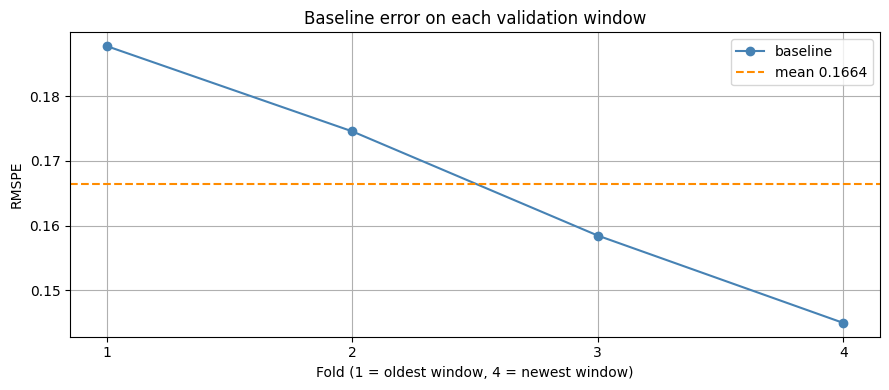

In [6]:
plt.plot(results["fold"].to_list(), results["rmspe"].to_list(),
         marker="o", color="steelblue", label="baseline")
plt.axhline(mean_score, color="darkorange", linestyle="--", label=f"mean {mean_score:.4f}")
plt.xticks(results["fold"].to_list())
plt.xlabel("Fold (1 = oldest window, 4 = newest window)")
plt.ylabel("RMSPE")
plt.title("Baseline error on each validation window")
plt.legend()
plt.tight_layout()
plt.show()

## Why are the older windows harder?

The error falls in a straight line as we move forward in time. Three
explanations are possible, and we can test them.

1. **History.** Later folds train on more days, so their medians are better.
2. **Renovation.** About 180 stores left the data for six months in 2014. They
   may hurt the older windows more.
3. **The season itself.** Spring may simply be harder to predict than summer.

We start with the history. If we give every fold **the same** training data,
and the trend stays, then history is not the reason.

In [7]:
fixed_train = folds[0].train  # everything up to 2015-02-13, for every fold

print("Same training data for all four windows:")
for fold in folds:
    s = baseline(fixed_train, fold.valid)
    print(f"  fold {fold.index} ({fold.valid_start} to {fold.valid_end}): "
          f"{rmspe(s['Sales'], s['prediction']):.4f}")

Same training data for all four windows:
  fold 1 (2015-02-14 to 2015-03-27): 0.1877
  fold 2 (2015-03-28 to 2015-05-08): 0.1764
  fold 3 (2015-05-09 to 2015-06-19): 0.1625


  fold 4 (2015-06-20 to 2015-07-31): 0.1509


The trend is still there: 0.1877, 0.1764, 0.1625, 0.1509.

So history is **not** the main reason. It does help a little. With a growing
training set the newest fold reaches 0.1449 instead of 0.1509, so the extra
four months of data are worth about 0.006. But the whole trend is about 0.037,
which is six times larger.

Now the renovated stores. We find them by looking for stores with no rows at
all in the second half of 2014.

In [8]:
all_stores = set(df["Store"].unique().to_list())
active_2014_h2 = set(
    df.filter((pl.col("Date") >= date(2014, 7, 1)) & (pl.col("Date") <= date(2014, 12, 31)))
    ["Store"].unique().to_list()
)
renovated = sorted(all_stores - active_2014_h2)
print(f"Stores with no rows in the second half of 2014: {len(renovated)}")

print("\nfold | renovated | the others | all stores | effect")
for fold in folds:
    s = scored[fold.index]
    part = s.filter(pl.col("Store").is_in(renovated))
    rest = s.filter(~pl.col("Store").is_in(renovated))
    r_part = rmspe(part["Sales"], part["prediction"])
    r_rest = rmspe(rest["Sales"], rest["prediction"])
    r_all = rmspe(s["Sales"], s["prediction"])
    print(f"  {fold.index}  |  {r_part:.4f}   |   {r_rest:.4f}   |   {r_all:.4f}   | {r_all - r_rest:+.4f}")

Stores with no rows in the second half of 2014: 180

fold | renovated | the others | all stores | effect
  1  |  0.2000   |   0.1853   |   0.1877   | +0.0024
  2  |  0.1708   |   0.1753   |   0.1746   | -0.0007
  3  |  0.1592   |   0.1583   |   0.1584   | +0.0001
  4  |  0.1550   |   0.1429   |   0.1449   | +0.0020


These 180 stores are indeed harder in the oldest window, but there are not
enough of them to move the total. They change the score by 0.0024 at most, and
in one fold they even make it slightly better. The trend across the folds stays
the same without them.

So the third explanation is the one that survives: **the season itself**. The
spring windows are harder to predict than the summer windows, even with the
same training data and the same stores.

We could not pin down the exact cause. Public holidays do not explain it,
because the hardest window (fold 1) and the easiest window (fold 4) both
contain none. The sales inside the windows are not more variable either.

### What this means for us

The real test period is August and September 2015. None of our windows covers
those months, so we should stay careful with any single number.

For comparing models, we use the **average over the four folds**. It is more
stable than one window, and a model that wins on all four folds is a real
winner. We will also check every fold on its own, so that a model cannot hide a
weakness behind a good average.

## Where does the error sit?

The average hides a lot. `rmspe_by` splits the error by any column, and this is
how we will find the weak spots of the model later. Here we look at the newest
window.

In [9]:
newest = scored[4]

print("By store type")
print(rmspe_by(newest, "StoreType"))

# Store size, measured on the training rows of that fold, so we do not peek
# into the window we are scoring.
size = folds[-1].train.group_by("Store").agg(pl.col("Sales").mean().alias("mean_sales"))
cuts = np.percentile(size["mean_sales"].to_numpy(), [25, 50, 75])
size = size.with_columns(
    pl.when(pl.col("mean_sales") < cuts[0]).then(pl.lit("Q1 small"))
    .when(pl.col("mean_sales") < cuts[1]).then(pl.lit("Q2"))
    .when(pl.col("mean_sales") < cuts[2]).then(pl.lit("Q3"))
    .otherwise(pl.lit("Q4 large"))
    .alias("size_group")
)

print("\nBy store size")
print(
    rmspe_by(newest.join(size.select(["Store", "size_group"]), on="Store", how="left"),
             "size_group").sort("size_group")
)

By store type
shape: (4, 4)
┌───────────┬──────────┬───────┬──────────────┐
│ StoreType ┆ rmspe    ┆ rows  ┆ mean_sales   │
│ ---       ┆ ---      ┆ ---   ┆ ---          │
│ str       ┆ f64      ┆ u32   ┆ f64          │
╞═══════════╪══════════╪═══════╪══════════════╡
│ b         ┆ 0.152588 ┆ 714   ┆ 10808.666667 │
│ a         ┆ 0.148706 ┆ 21694 ┆ 6876.243985  │
│ c         ┆ 0.146895 ┆ 5328  ┆ 6885.941817  │
│ d         ┆ 0.136839 ┆ 12546 ┆ 6977.090308  │
└───────────┴──────────┴───────┴──────────────┘

By store size
shape: (4, 4)
┌────────────┬──────────┬───────┬──────────────┐
│ size_group ┆ rmspe    ┆ rows  ┆ mean_sales   │
│ ---        ┆ ---      ┆ ---   ┆ ---          │
│ str        ┆ f64      ┆ u32   ┆ f64          │
╞════════════╪══════════╪═══════╪══════════════╡
│ Q1 small   ┆ 0.149773 ┆ 10063 ┆ 4607.278744  │
│ Q2         ┆ 0.152093 ┆ 10039 ┆ 6002.824883  │
│ Q3         ┆ 0.136725 ┆ 10098 ┆ 7257.489206  │
│ Q4 large   ┆ 0.140674 ┆ 10082 ┆ 10037.886035 │
└────────────┴────────

Both breakdowns are surprisingly flat.

Store type `b` has the largest error, but it holds only 714 rows, so its number
is not stable. Type `d` is the easiest.

The store size tells a similar story. The error goes from 0.137 to 0.152, and
it does not fall in a straight line: the second quartile is the hardest and the
third one is the easiest. Small stores are **not** much harder than large ones
in percentage terms.

This is useful for the next steps. If small stores had an error of 0.25 and
large stores an error of 0.09, we would think about separate models for
different store groups. They do not, so one model for all stores looks like the
better plan.

## Key findings

1. The baseline scores **0.1664** on average over the four windows. Every model
   we build must beat this number, and it should beat it on every window.
2. A single window would have reported **0.1449**, which is the friendliest of
   the four results. This is why we use four windows and not one.
3. The windows are not equally hard, and the reason is the season, not the
   length of the history and not the renovated stores. We tested all three.
4. The error is flat across store types and store sizes. This is an early
   argument for one single model instead of one model per store group.
5. The tools are ready. `rmspe`, `rmspe_by` and `RollingOriginSplit` are now
   the measuring stick for every experiment that follows.